/data/gravwav/koley/my_venv/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1.2, ObsPy can read versions (1.0, 1.1). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "


Processing TEUV loc 00
Day 2 in progress for TEUV loc 00
Day 3 in progress for TEUV loc 00
Day 4 in progress for TEUV loc 00
Day 5 in progress for TEUV loc 00
Day 6 in progress for TEUV loc 00
Day 7 in progress for TEUV loc 00
Day 8 in progress for TEUV loc 00
Day 9 in progress for TEUV loc 00
Day 10 in progress for TEUV loc 00
Processing TEUV loc 01
Day 2 in progress for TEUV loc 01
Day 3 in progress for TEUV loc 01
Day 4 in progress for TEUV loc 01
Day 5 in progress for TEUV loc 01
Day 6 in progress for TEUV loc 01
Day 7 in progress for TEUV loc 01
Day 8 in progress for TEUV loc 01
Day 9 in progress for TEUV loc 01
Day 10 in progress for TEUV loc 01


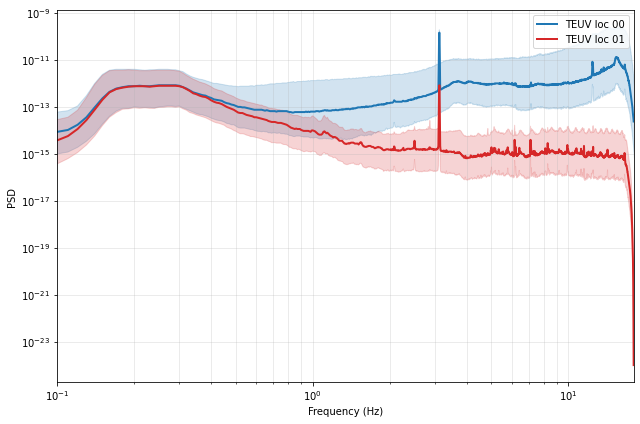

In [4]:
import os
import datetime
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sp

from obspy import read_inventory, UTCDateTime
from obspy.clients.filesystem.sds import Client

# --------------------------------------------------
# Configuration
# --------------------------------------------------
rootP2 = '/dcache/etseis/et/EMR/Data'
archiveP2 = Client(rootP2)

respPath = '/dcache/etseis/et/EMR/Stations/Stations/NL.TEUV.xml'
invNow = read_inventory(respPath)

stnName = 'TEUV'
preFilt = [0.05, 0.1, 16, 18]

dateStVec = np.array([1])
yearVec = np.array([2026])
nDays = 10

readLen = 3600      # read 1 hour at a time
fSamp_target = 40.0

# PSD settings: 3600 s windows with 50% overlap
psdLen = 100
psdOverlap = 50
psdStep = psdLen - psdOverlap

dayNow = int(dateStVec[0])
yearNow = int(yearVec[0])

A = datetime.datetime(yearNow, 1, 1) + datetime.timedelta(days=dayNow - 1)
dateUse = UTCDateTime(A.year, A.month, A.day)

totHoursPerDay = int(86400 // readLen)

# --------------------------------------------------
# Histogram settings in log10(PSD)
# --------------------------------------------------
logPsdMin = -24
logPsdMax = -8
nHistBins = 800

hist_edges = np.linspace(logPsdMin, logPsdMax, nHistBins + 1)
hist_centers = 0.5 * (hist_edges[:-1] + hist_edges[1:])

# --------------------------------------------------
# Channel configuration
# --------------------------------------------------
configs = [
    {
        "label": f"{stnName} loc 00",
        "station": "TEUV",
        "network": "NL",
        "location": "00",
        "channel": "BHZ",
        "inventory": invNow,
        "use_prefilt": False,
        "color": "tab:blue",
    },
    {
        "label": f"{stnName} loc 01",
        "station": "TEUV",
        "network": "NL",
        "location": "01",
        "channel": "BHZ",
        "inventory": invNow,
        "use_prefilt": True,
        "color": "tab:red",
    },
]

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def fetch_corrected_trace(archive, cfg, starttime, endtime):
    try:
        st = archive.get_waveforms(
            station=cfg["station"],
            channel=cfg["channel"],
            network=cfg["network"],
            location=cfg["location"],
            starttime=starttime,
            endtime=endtime
        )
        if not st:
            return None, None

        tr = st[0].copy()
        tr.trim(starttime=starttime, endtime=endtime, pad=True, fill_value=0)

        fs = float(tr.stats.sampling_rate)

        remove_kwargs = dict(
            inventory=cfg["inventory"],
            output='VEL',
            zero_mean=True,
            hide_sensitivity_mismatch_warning=True
        )
        if cfg["use_prefilt"]:
            remove_kwargs["pre_filt"] = preFilt

        tr.remove_response(**remove_kwargs)
        tr.trim(starttime=starttime, endtime=endtime, pad=True, fill_value=0)

        return tr.data.astype(np.float64), fs

    except Exception as e:
        print(f"Failed for {cfg['label']} at {starttime}: {e}")
        return None, None


def update_histogram_from_psd(Pxx, fVec, hist_counts, n_samples):
    Pxx = Pxx * (2 * np.pi * fVec) ** 2
    Pxx[Pxx <= 0] = np.finfo(float).tiny
    logP = np.log10(Pxx)

    bin_idx = np.clip(
        np.searchsorted(hist_edges, logP, side='right') - 1,
        0,
        nHistBins - 1
    )

    freq_idx = np.arange(len(logP))
    hist_counts[freq_idx, bin_idx] += 1
    n_samples += 1


def percentiles_from_hist(hist_counts, probs):
    cdf = np.cumsum(hist_counts, axis=1)
    totals = cdf[:, -1].copy()

    out = {}
    valid_rows = totals > 0

    for p in probs:
        arr = np.full(hist_counts.shape[0], np.nan, dtype=float)
        if np.any(valid_rows):
            cdf_norm = np.zeros_like(cdf, dtype=float)
            cdf_norm[valid_rows] = cdf[valid_rows] / totals[valid_rows, None]
            idx = np.argmax(cdf_norm >= p, axis=1)
            arr[valid_rows] = 10 ** hist_centers[idx[valid_rows]]
        out[p] = arr

    return out


# --------------------------------------------------
# Main processing
# --------------------------------------------------
results = []
fVec_global = None

for cfg in configs:
    print(f"Processing {cfg['label']}")

    hist_counts = None
    n_samples = None
    startDay = dateUse.julday

    # buffer so consecutive 1-hour reads can build 50%-overlapped 3600 s PSD windows
    data_buffer = np.array([], dtype=np.float64)
    fs_buffer = None

    for dayNo in range(nDays):
        for hourNo in range(totHoursPerDay):
            Start = dateUse + hourNo * readLen + dayNo * 86400
            eTime = Start + readLen
            dayNow = Start.julday

            if dayNow > startDay:
                print(f"Day {dayNow} in progress for {cfg['label']}")
                startDay = dayNow

            data, fs = fetch_corrected_trace(archiveP2, cfg, Start, eTime)

            if data is None:
                print(f"Insufficient data for {cfg['label']} at {Start}")
                continue

            if fs_buffer is None:
                fs_buffer = fs
            elif fs != fs_buffer:
                print(f"Sampling rate changed for {cfg['label']} at {Start}, skipping segment")
                continue

            data_buffer = np.concatenate([data_buffer, data])

            samples_per_psd = int(psdLen * fs)
            step_samples = int(psdStep * fs)

            while len(data_buffer) >= samples_per_psd:
                seg = data_buffer[:samples_per_psd]

                fVec, Pxx = sp.welch(
                    seg,
                    fs=fs,
                    window='hann',
                    nperseg=samples_per_psd,
                    noverlap=samples_per_psd // 2,   # 50% overlap inside Welch too
                    nfft=samples_per_psd,
                    detrend='constant'
                )

                if hist_counts is None:
                    fVec_global = fVec
                    hist_counts = np.zeros((len(fVec), nHistBins), dtype=np.int64)
                    n_samples = np.zeros(len(fVec), dtype=np.int64)

                update_histogram_from_psd(Pxx, fVec, hist_counts, n_samples)

                # slide by 1800 s
                data_buffer = data_buffer[step_samples:]

    pct = percentiles_from_hist(hist_counts, probs=[0.1, 0.5, 0.9])

    results.append({
        "label": cfg["label"],
        "color": cfg["color"],
        "p10": pct[0.1],
        "p50": pct[0.5],
        "p90": pct[0.9],
    })

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(9, 6))

for res in results:
    valid = (
        np.isfinite(res["p10"]) &
        np.isfinite(res["p50"]) &
        np.isfinite(res["p90"]) &
        (res["p10"] > 0) &
        (res["p50"] > 0) &
        (res["p90"] > 0) &
        (fVec_global > 0)
    )

    if not np.any(valid):
        continue

    fplot = fVec_global[valid]
    p10 = res["p10"][valid]
    p50 = res["p50"][valid]
    p90 = res["p90"][valid]

    plt.fill_between(
        fplot, p10, p90,
        color=res["color"],
        alpha=0.20
    )
    plt.plot(
        fplot, p50,
        color=res["color"],
        linewidth=2.0,
        label=res["label"]
    )

plt.xscale('log')
plt.yscale('log')
plt.xlim(0.1, 18)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

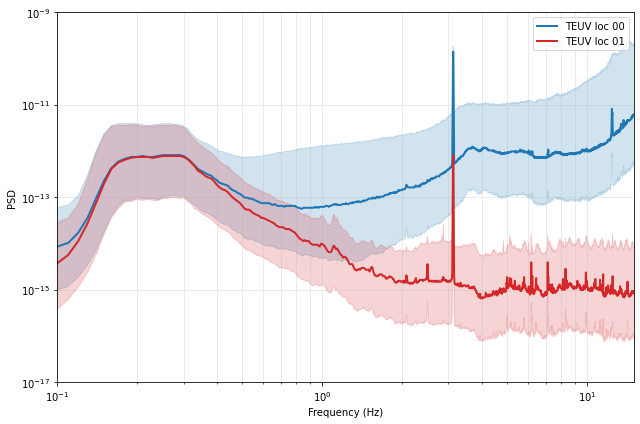

In [5]:
# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(9, 6))

for res in results:
    valid = (
        np.isfinite(res["p10"]) &
        np.isfinite(res["p50"]) &
        np.isfinite(res["p90"]) &
        (res["p10"] > 0) &
        (res["p50"] > 0) &
        (res["p90"] > 0) &
        (fVec_global > 0)
    )

    if not np.any(valid):
        continue

    fplot = fVec_global[valid]
    p10 = res["p10"][valid]
    p50 = res["p50"][valid]
    p90 = res["p90"][valid]

    plt.fill_between(
        fplot, p10, p90,
        color=res["color"],
        alpha=0.20
    )
    plt.plot(
        fplot, p50,
        color=res["color"],
        linewidth=2.0,
        label=res["label"]
    )

plt.xscale('log')
plt.yscale('log')
plt.xlim(0.1, 15)
plt.ylim(10**-17, 10**-9)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()